In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from IPython.display import display

%matplotlib inline

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "src").is_dir()
)
source_path = project_root / "data" / "synthetic" / "gbm_scheduled_samples.csv"

regime_names = {0: "Regime 0", 1: "Regime 1", 2: "Regime 2"}
palette = ["#0072B2", "#D55E00", "#8E5EA2", "#009E73", "#CC79A7"]

In [6]:
df = pd.read_csv(source_path).sort_values("time").reset_index(drop=True)
required = ["time", "state", "data", "price"]


times = df["time"].to_numpy()
prices = df["price"].to_numpy()
log_returns = df["data"].to_numpy()
states = df["state"].to_numpy(dtype=int)
regimes = sorted(np.unique(states))
colors = {state: palette[i % len(palette)] for i, state in enumerate(regimes)}
labels = {state: regime_names.get(state, f"Regime {state}") for state in regimes}
initial_price = np.exp(np.log(prices[0]) - log_returns[0])

# Each segment begins at the start of its first return interval.
starts = np.r_[0, np.flatnonzero(states[1:] != states[:-1]) + 1]
stops = np.r_[starts[1:], len(df)]  # exclusive row indices
segments = []
for start, stop in zip(starts, stops):
    segments.append({
        "Regime": labels[states[start]],
        "First observation": int(start + 1),
        "Last observation": int(stop),
        "Observations": int(stop - start),
        "Start year": float(times[start - 1]) if start else 0.0,
        "End year": float(times[stop - 1]),
    })
segment_table = pd.DataFrame(segments)

# Check that the stored prices compound the same log returns being plotted.
np.testing.assert_allclose(
    np.diff(np.log(np.r_[initial_price, prices])), log_returns, atol=1e-12
)
print(f"Source: {source_path.relative_to(project_root)}")
print(f"{len(df):,} observations | {len(regimes)} regimes | {len(segments)} segments")
display(segment_table.style.format({"Start year": "{:.2f}", "End year": "{:.2f}"}).hide(axis="index"))

Source: data/synthetic/gbm_scheduled_samples.csv
10,000 observations | 3 regimes | 4 segments


Regime,First observation,Last observation,Observations,Start year,End year
Regime 0,1,2500,2500,0.00,9.92
Regime 1,2501,5000,2500,9.92,19.84
Regime 2,5001,7500,2500,19.84,29.76
Regime 0,7501,10000,2500,29.76,39.68


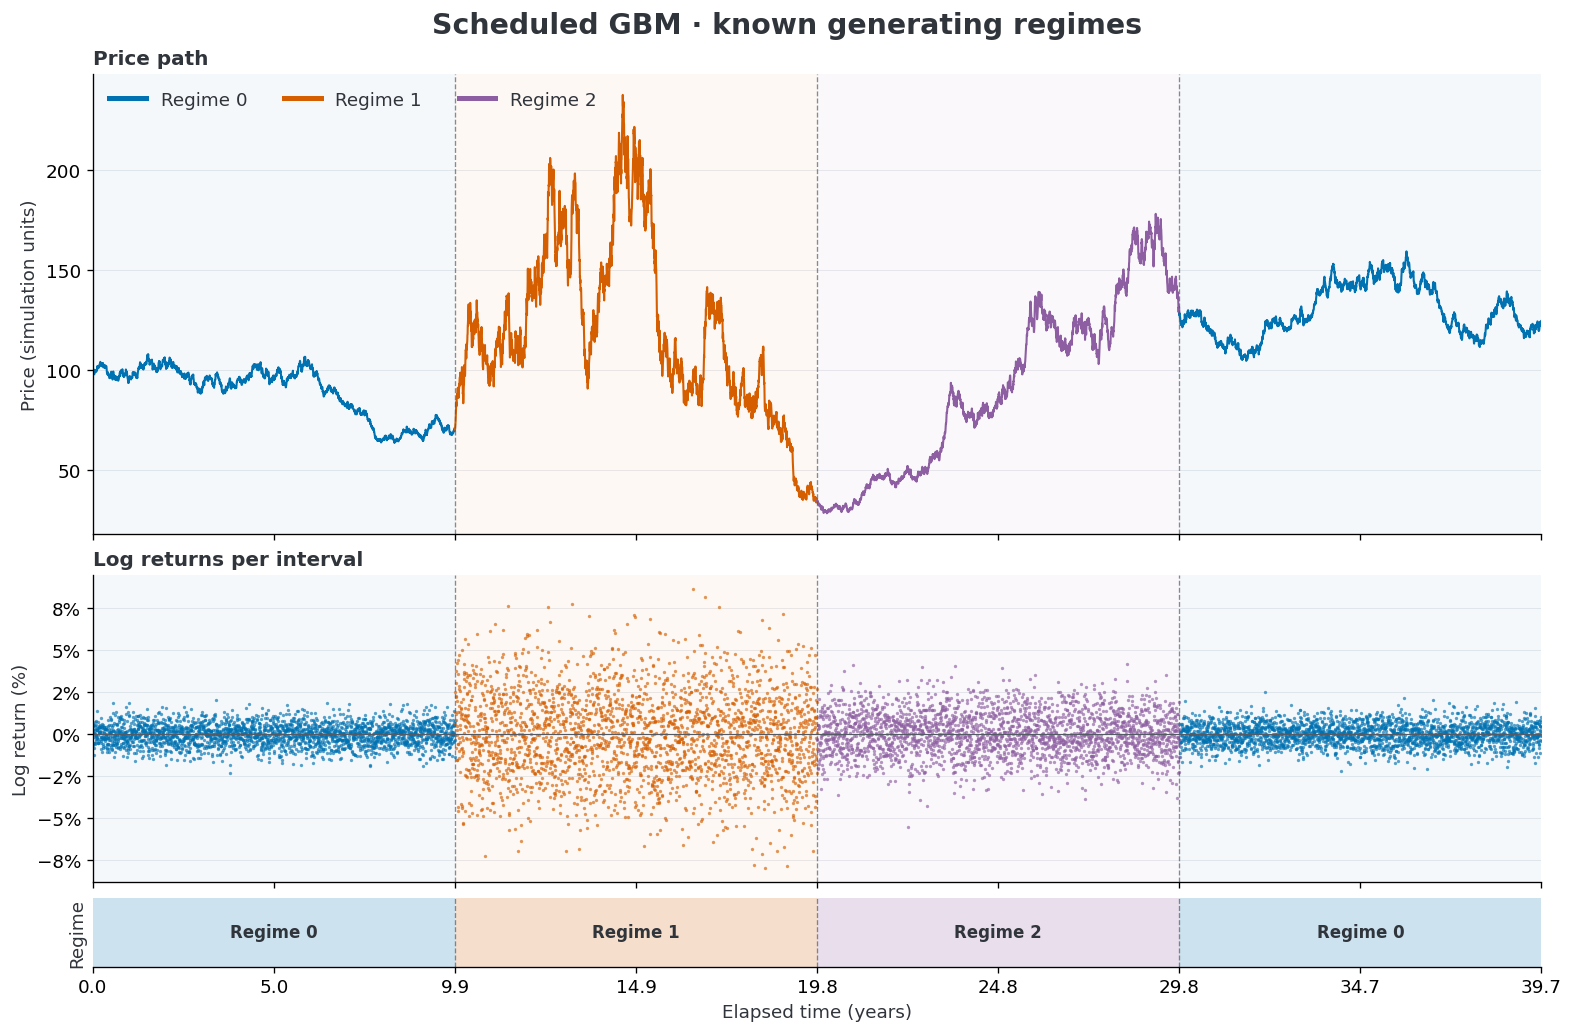

In [7]:
fig, axes = plt.subplots(
    3, 1, figsize=(13, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 2, 0.45]},
    layout="constrained",
)
price_ax, return_ax, regime_ax = axes
fig.suptitle("Scheduled GBM · known generating regimes", fontsize=17, fontweight="bold")

for start, stop, segment in zip(starts, stops, segments):
    state = states[start]
    color = colors[state]
    left, right = segment["Start year"], segment["End year"]
    previous_price = prices[start - 1] if start else initial_price
    price_ax.plot(
        np.r_[left, times[start:stop]],
        np.r_[previous_price, prices[start:stop]],
        color=color, linewidth=1.25,
    )
    for ax in (price_ax, return_ax):
        ax.axvspan(left, right, color=color, alpha=0.045, linewidth=0)
    regime_ax.axvspan(left, right, color=color, alpha=0.20, linewidth=0)
    regime_ax.text(
        (left + right) / 2, 0.5, labels[state],
        transform=regime_ax.get_xaxis_transform(),
        ha="center", va="center", fontsize=10, fontweight="bold",
    )

for state in regimes:
    mask = states == state
    return_ax.scatter(times[mask], log_returns[mask], s=4, alpha=0.65,
                      color=colors[state], linewidths=0, rasterized=True)

for boundary in segment_table["Start year"].iloc[1:]:
    for ax in axes:
        ax.axvline(boundary, color="#555B65", linewidth=0.8, linestyle="--", alpha=0.7)

price_ax.set_title("Price path", loc="left")
price_ax.set_ylabel("Price (simulation units)")
price_ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
price_ax.legend(
    handles=[Line2D([0], [0], color=colors[state], lw=3, label=labels[state]) for state in regimes],
    loc="upper left", ncol=min(3, len(regimes)), frameon=False,
)
return_ax.set_title("Log returns per interval", loc="left")
return_ax.set_ylabel("Log return (%)")
return_ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
return_ax.axhline(0, color="#555B65", linewidth=0.7)
for ax in (price_ax, return_ax):
    ax.grid(axis="y", linewidth=0.6)
    ax.set_axisbelow(True)
regime_ax.set_ylim(0, 1)
regime_ax.set_yticks([])
regime_ax.set_ylabel("Regime")
regime_ax.set_xlabel("Elapsed time (years)")
regime_ax.spines["left"].set_visible(False)
regime_ax.set_xlim(0, times[-1])
regime_ax.set_xticks(np.linspace(0, times[-1], 9))
regime_ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.1f}"))
plt.show()